# Finding other important rates

In [1]:
import pynucastro as pyna
import mesa_reader as mr

In [2]:
from pynucastro import mesa_utils
from pynucastro.screening import chugunov_2007

## Read in the MESA model

In [3]:
model = mr.MesaData("lab3/profile2.data")

In [4]:
nuclei = mesa_utils.get_nuclei(model)

In [5]:
nuclei

[H1,
 He4,
 O16,
 O20,
 F20,
 Ne20,
 Ne23,
 Ne24,
 Ne25,
 Na23,
 Na24,
 Na25,
 Mg24,
 Mg25,
 Si28]

In [6]:
mesa_zones = mesa_utils.MesaModel(model)

## Create the network using the same species as the MESA model

### Full network

By default, `network_helper` will find all the rates connecting the nuclei, some of which were likely not used in the MESA simulation.

In [7]:
net_full = pyna.network_helper(nuclei)

In [8]:
net_full.summary()

Network summary
---------------
  explicitly carried nuclei: 15
  approximated-out nuclei: 0
  inert nuclei (included in carried): 0

  NSE compatible? False

  total number of rates: 38

  rates explicitly connecting nuclei: 38
  hidden rates: 0

  reaclib rates: 12
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 14
  approximate rates: 0
  derived rates: 12
  branched rates: 0
  modified rates: 0
  custom rates: 0


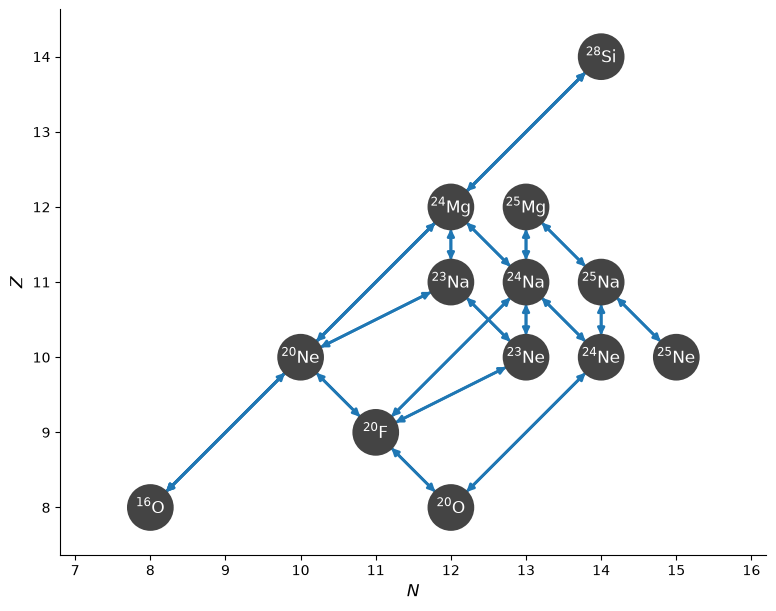

In [9]:
fig = net_full.plot()

### reduced network

separately create a network that has just the rates that we used in MESA.

In [10]:
rl = pyna.ReacLibLibrary()
tl = pyna.TabularLibrary()
all_lib = rl + tl

/tmp/ipykernel_3104218/94239008.py:2: DeprecationWarning: TabularLibrary is deprecated; use TabularWeakLibrary instead.
  tl = pyna.TabularLibrary()


The MESA run uses a rate that approximates the ${}^{16}\mathrm{O} + {}^{16}\mathrm{O}$ burning through ${}^{31}\mathrm{P}$.  We'll create that rate first.

In [11]:
from pynucastro.rates.aprox_family_rates import make_CO_approx_rates
o_rates = make_CO_approx_rates(rl.get_rates(), "O")
o_lib = pyna.Library(rates=o_rates)
r1616 = o_lib.get_rate_by_name("o16(o16,a)si28")
type(r1616)

pynucastro.rates.approximate_rates.ApproximateRate

We see that `r1616` is an `ApproximateRate` that will carry multiple rates to do the approximation.

Now get all the weak rates we used in the MESA simulation

In [12]:
rate_names = ["ne20(,)f20", "f20(,)ne20",
              "f20(,)o20", "o20(,)f20",
              "mg24(,)na24", "na24(,)mg24",
              "na24(,)ne24", "ne24(,)na24",
              "na23(,)ne23", "ne23(,)na23",
              "mg25(,)na25", "na25(,)mg25",
              "na25(,)ne25", "ne25(,)na25"]


In [13]:
rates = all_lib.get_rate_by_name(rate_names)

and put it all together, eliminating any duplicates (e.g. ReacLib and Suzuki both provide the link---we prefer the Suzuki)

In [14]:
lib = pyna.Library(rates=[r1616] + rates)
lib.eliminate_duplicates()

In [15]:
net = pyna.PythonNetwork(libraries=lib)

In [16]:
net.summary()

Network summary
---------------
  explicitly carried nuclei: 14
  approximated-out nuclei: 1
  inert nuclei (included in carried): 0

  NSE compatible? False

  total number of rates: 22

  rates explicitly connecting nuclei: 15
  hidden rates: 7

  reaclib rates: 7
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 14
  approximate rates: 1
  derived rates: 0
  branched rates: 0
  modified rates: 0
  custom rates: 0


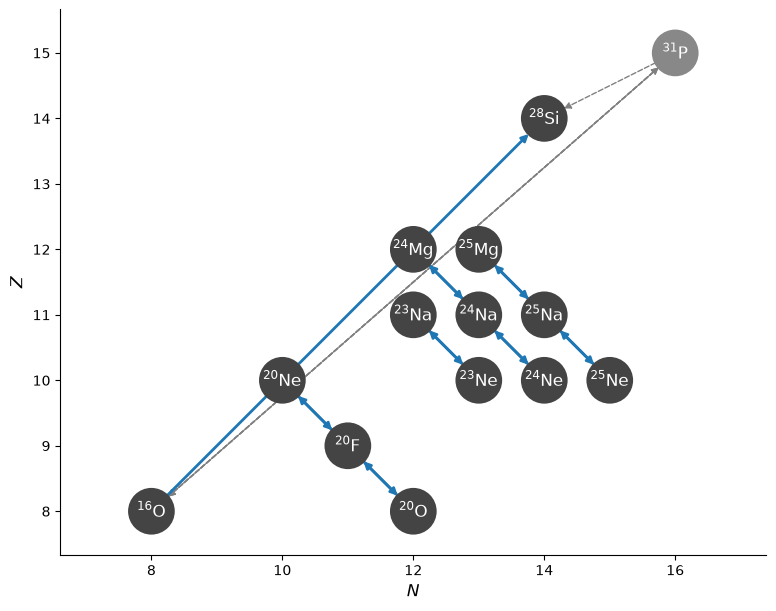

In [17]:
fig = net.plot()

## Check nuclei for other branches

In [18]:
full_library = pyna.full_library()

In [19]:
_, missing_rates = net.validate(full_library, return_dict=True)

validation: Si28 produced in O16 + O16 ⟶ Si28 + He4 never consumed.
validation: He4 produced in O16 + O16 ⟶ Si28 + He4 never consumed.


In [20]:
len(missing_rates)

162

This finds 162 other potential rates.  But this includes a lot of duplicates (like StarLib rates vs. ReacLib rates).  Let's eliminate the StarLib rates

In [21]:
trimmed_rates = [r for r in missing_rates.keys()
                 if not isinstance(r, pyna.rates.StarLibRate)]

In [22]:
len(trimmed_rates)

82

## Determine if any missing rates are important

We'll pick some zones from the MESA model to consider

In [23]:
import numpy as np

In [24]:
zones = np.linspace(385, 785, 11, dtype=int)
zones

array([385, 425, 465, 505, 545, 585, 625, 665, 705, 745, 785])

We only consider a rate important if it is within this threshold for the fastest capture on the same nucleus.  Since some existing rates may be very small, we also put a floor, `ydot_cutoff` on the # of reactions / sec we care about

In [25]:
thresh = 0.2
ydot_cutoff = 1.e-15

In [26]:
possibly_important = []

for izone in zones:
    state = mesa_zones.get_zone_data(izone)
    for nuc in net.unique_nuclei:
        thermo = pyna.ThermoState(rho=state.rho,
                                  T=state.T,
                                  comp=state.comp)
        
        # evaluate all existing rates working with this nucleus
        r_current = {r : r.eval_full_rate(thermo,
                                          screen_func=chugunov_2007)
                     for r in net.get_rates() if nuc == max(r.reactants)}

        # evaluate all missing rates working with this nucleus
        r_missing = {r : r.eval_full_rate(thermo,
                                          screen_func=chugunov_2007)
                     for r in trimmed_rates if nuc == max(r.reactants)}

        # compute the fastest (abs value) current rate consuming this nucleus
        if not (r_current and r_missing):
            continue
        
        r_fastest = max(r_current, key=r_current.get)
        lambda_fastest = r_current[r_fastest]

        # now check if any missing rate is within the threshold
        possibly_important += [r for r, v in r_missing.items()
                               if v > max(ydot_cutoff, thresh * lambda_fastest)]

possibly_important = set(possibly_important)

In [27]:
possibly_important

{O16 + He4 ⟶ Ne20 + 𝛾,
 O16 + O16 ⟶ p + P31,
 O16 + O16 ⟶ n + S31,
 O20 + He4 ⟶ p + F23,
 O20 + He4 ⟶ n + Ne23,
 O20 + He4 ⟶ Ne24 + 𝛾,
 F20 + He4 ⟶ p + Ne23,
 F20 + He4 ⟶ n + Na23,
 F20 + He4 ⟶ Na24 + 𝛾,
 Ne20 + He4 ⟶ p + Na23,
 Ne20 + He4 ⟶ Mg24 + 𝛾,
 Ne23 + e⁻ ⟶ F23 + 𝜈,
 Ne23 + He4 ⟶ p + Na26,
 Ne23 + He4 ⟶ n + Mg26,
 Ne23 ⟶ n + Ne22,
 Ne23 + He4 ⟶ Mg27 + 𝛾,
 Ne24 + He4 ⟶ n + Mg27,
 Ne24 + He4 ⟶ Mg28 + 𝛾,
 Ne25 ⟶ n + Ne24,
 Ne25 + He4 ⟶ n + Mg28,
 Ne25 + He4 ⟶ Mg29 + 𝛾,
 Na23 + He4 ⟶ p + Mg26,
 Na25 + He4 ⟶ p + Mg28,
 Na25 + He4 ⟶ n + Al28,
 Na25 + He4 ⟶ Al29 + 𝛾}

which of these involve only the nuclei we are already carrying? (also allow protons)

In [28]:
okay_nuc = net.unique_nuclei + [pyna.Nucleus("p")]
filtered_rates = []
for r in possibly_important:
    okay = True
    for nuc in r.reactants + r.products:
        if nuc not in okay_nuc:
            okay = False
            break
    if okay:
        filtered_rates.append(r)

In [29]:
for r in filtered_rates:
    print(f"{r!s:25} {type(r).__name__}")

F20 + He4 ⟶ p + Ne23      ReacLibRate
F20 + He4 ⟶ Na24 + 𝛾      ReacLibRate
Ne20 + He4 ⟶ Mg24 + 𝛾     ReacLibRate
O20 + He4 ⟶ Ne24 + 𝛾      ReacLibRate
O16 + He4 ⟶ Ne20 + 𝛾      ReacLibRate
Ne20 + He4 ⟶ p + Na23     ReacLibRate


## Network with all missing rates

In [30]:
rates = net.get_rates() + list(possibly_important)

In [31]:
big_net = pyna.PythonNetwork(rates=rates)

In [32]:
big_net.summary()

Network summary
---------------
  explicitly carried nuclei: 27
  approximated-out nuclei: 0
  inert nuclei (included in carried): 0

  NSE compatible? False

  total number of rates: 46

  rates explicitly connecting nuclei: 40
  hidden rates: 6

  reaclib rates: 30
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 15
  approximate rates: 1
  derived rates: 0
  branched rates: 0
  modified rates: 0
  custom rates: 0


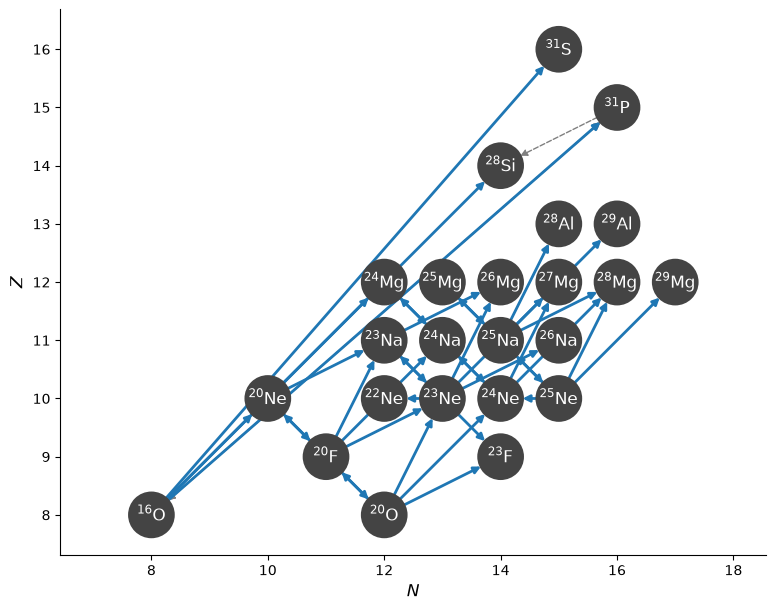

In [33]:
fig = big_net.plot()

what if we restrict it to just the rates that use the same nuclei?

In [34]:
rates = net.get_rates() + list(filtered_rates)

In [35]:
new_net = pyna.PythonNetwork(rates=rates)

In [36]:
new_net.summary()

Network summary
---------------
  explicitly carried nuclei: 15
  approximated-out nuclei: 1
  inert nuclei (included in carried): 0

  NSE compatible? False

  total number of rates: 28

  rates explicitly connecting nuclei: 21
  hidden rates: 7

  reaclib rates: 13
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 14
  approximate rates: 1
  derived rates: 0
  branched rates: 0
  modified rates: 0
  custom rates: 0


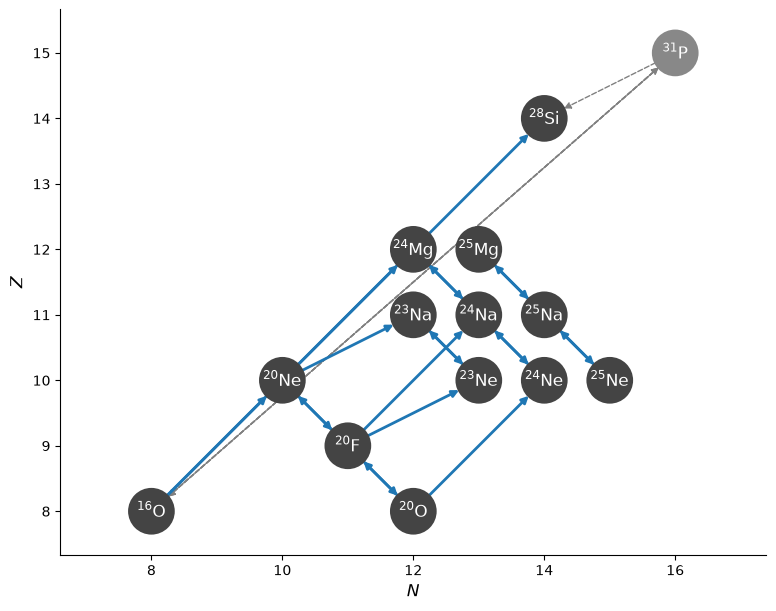

In [37]:
fig = new_net.plot()